# Simplex Projection — Core Validation on One Session

Validate simplex projection on matched Raw and Processed PPG windows
from one session. Results are exploratory and are not used for
statistical or physiological inference.

## Cell 1 — Imports and configuration

All experimental choices are defined here. Parameters marked as
baseline are temporary and remain subject to sensitivity analysis.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display


def find_project_root():
    '''Find the repository root from the current directory.'''
    candidates = (Path.cwd(), *Path.cwd().parents)
    for candidate in candidates:
        if (candidate / "phase1" / "src").is_dir():
            return candidate
    raise FileNotFoundError("Cannot locate the project root.")


PROJECT_ROOT = find_project_root()
SRC_DIR = PROJECT_ROOT / "phase1" / "src"
OUTPUT_DIR = PROJECT_ROOT / "phase1" / "results" / "simplex_projection"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from dataloader.loader import get_data
from prediction.simplex_projection import (
    prediction_metrics,
    simplex_projection,
)

SESSION = "sample_1.csv"
WINDOW_SIZE_SECONDS = 60
STATIONARITY_POLICY = "both"

EMBEDDING_DIMENSION = 8
TAU_SECONDS = {"Raw": 0.20, "Processed": 0.16}

THEILER_SECONDS = 1.00
HORIZON_SECONDS = np.array([
    0.04,
    0.08,
    0.12,
    0.16,
    0.20,
    0.28,
    0.40,
    0.60,
    0.80,
    1.00,
    1.20,
    1.60,
    2.00,
])

SIGNAL_NORMALIZATION = "window z-score"
NRMSE_NORMALIZATION = "target standard deviation"
CC_COLLAPSE_LEVEL = 0.50
NRMSE_PLATEAU_TOLERANCE = 0.05
NRMSE_PLATEAU_MIN_POINTS = 3
EXTREME_NRMSE_LEVEL = 5.00

STATE_COLORS = {"Awake": "#4472C4", "Drowsy": "#ED7D31"}
plt.style.use("seaborn-v0_8-whitegrid")

## Cell 2 — Load selected-session windows

`stationarity="both"` retains matched windows that pass stationarity
for both representations. Exported windows have already passed SQI.

In [2]:
data_awake, data_drowsy = get_data(
    SESSION,
    window_sizes=WINDOW_SIZE_SECONDS,
    stationarity=STATIONARITY_POLICY,
)

state_batches = {
    "Awake": data_awake[WINDOW_SIZE_SECONDS],
    "Drowsy": data_drowsy[WINDOW_SIZE_SECONDS],
}

availability_rows = []
for state, batch in state_batches.items():
    n_windows = len(batch["window_id"])
    assert n_windows > 0, f"No valid {state} windows."
    assert batch["time"].shape == batch["raw"].shape

    for key in ("raw", "processed", "time"):
        values = np.asarray(batch[key])
        assert values.ndim == 2
        assert np.all(np.isfinite(values))

    availability_rows.append({
        "session": SESSION,
        "state": state,
        "window_size_seconds": WINDOW_SIZE_SECONDS,
        "n_windows": n_windows,
        "n_samples": batch["n_samples"],
        "fs": batch["fs"],
    })

availability = pd.DataFrame(availability_rows)
display(availability)

,session,state,window_size_seconds,n_windows,n_samples,fs
0,sample_1.csv,Awake,60,14,3000,50.0
1,sample_1.csv,Drowsy,60,2,3000,50.0


## Cell 3 — Convert physical parameters to samples

Conversion is performed independently for each sampling frequency.
The selected horizon grid is exactly representable at 25 and 50 Hz.

In [3]:
def seconds_to_samples(seconds, fs):
    '''Convert positive physical durations to integer samples.'''
    values = np.asarray(seconds, dtype=float)
    samples = np.rint(values * fs).astype(int)
    if np.any(samples < 1):
        raise ValueError("Every duration must map to at least one sample.")
    return samples


sampling_rates = sorted({
    25.0,
    50.0,
    round(float(state_batches["Awake"]["fs"]), 6),
    round(float(state_batches["Drowsy"]["fs"]), 6),
})

conversion_rows = []
for fs in sampling_rates:
    horizon_samples = seconds_to_samples(HORIZON_SECONDS, fs)
    actual_seconds = horizon_samples / fs
    assert len(np.unique(horizon_samples)) == len(HORIZON_SECONDS)
    assert np.max(np.abs(actual_seconds - HORIZON_SECONDS)) <= 0.5 / fs

    for representation, tau_seconds in TAU_SECONDS.items():
        conversion_rows.append({
            "fs": fs,
            "representation": representation,
            "tau_seconds": tau_seconds,
            "tau_samples": int(
                seconds_to_samples(tau_seconds, fs)
            ),
            "theiler_seconds": THEILER_SECONDS,
            "theiler_samples": int(
                seconds_to_samples(THEILER_SECONDS, fs)
            ),
            "horizon_min_samples": int(horizon_samples.min()),
            "horizon_max_samples": int(horizon_samples.max()),
            "max_horizon_error_seconds": float(
                np.max(np.abs(actual_seconds - HORIZON_SECONDS))
            ),
        })

conversion_summary = pd.DataFrame(conversion_rows)
display(conversion_summary.round(6))

,fs,representation,tau_seconds,tau_samples,theiler_seconds,theiler_samples,horizon_min_samples,horizon_max_samples,max_horizon_error_seconds
0,25.0,Raw,0.20,5,1.0,25,1,50,0.0
1,25.0,Processed,0.16,4,1.0,25,1,50,0.0
2,50.0,Raw,0.20,10,1.0,50,2,100,0.0
3,50.0,Processed,0.16,8,1.0,50,2,100,0.0


## Cell 4 — Single-window smoke test

The first Awake Raw window is used only to verify output alignment,
finite predictions, valid coverage, and horizon-dependent output.

,horizon_seconds,horizon_samples,output_length,n_valid,valid_fraction
0,0.2,10,2920,2920,1.0
1,0.8,40,2890,2890,1.0


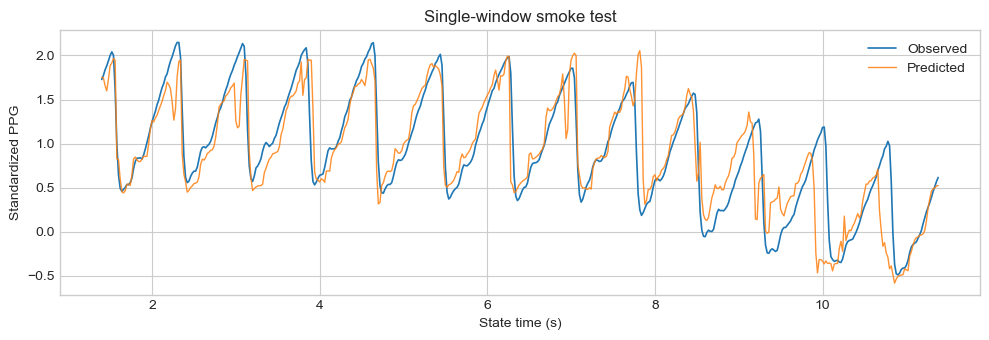

In [4]:
def standardize_window(signal):
    '''Return one window with zero mean and unit variance.'''
    signal = np.asarray(signal, dtype=float)
    scale = np.std(signal)
    if not np.isfinite(scale) or scale <= 0:
        raise ValueError("Signal variance must be positive and finite.")
    return (signal - np.mean(signal)) / scale


smoke_batch = state_batches["Awake"]
smoke_signal = standardize_window(smoke_batch["raw"][0])
smoke_fs = float(smoke_batch["fs"])
smoke_tau = int(
    seconds_to_samples(TAU_SECONDS["Raw"], smoke_fs)
)
smoke_theiler = int(
    seconds_to_samples(THEILER_SECONDS, smoke_fs)
)
smoke_horizons_seconds = (0.20, 0.80)
smoke_results = {}

for horizon_seconds in smoke_horizons_seconds:
    horizon_samples = int(
        seconds_to_samples(horizon_seconds, smoke_fs)
    )
    result = simplex_projection(
        signal=smoke_signal,
        tau=smoke_tau,
        m=EMBEDDING_DIMENSION,
        horizon=horizon_samples,
        theiler_window=smoke_theiler,
    )
    expected_length = (
        len(smoke_signal)
        - (EMBEDDING_DIMENSION - 1) * smoke_tau
        - horizon_samples
    )
    assert len(result.times) == expected_length
    assert result.y_true.shape == result.y_pred.shape
    assert result.valid.shape == result.y_pred.shape
    assert result.n_valid > 0
    assert np.all(np.isfinite(result.y_true))
    assert np.all(np.isfinite(result.y_pred[result.valid]))
    assert np.allclose(
        result.y_true,
        smoke_signal[result.times + horizon_samples],
    )
    smoke_results[horizon_seconds] = result

first_result = smoke_results[smoke_horizons_seconds[0]]
second_result = smoke_results[smoke_horizons_seconds[1]]
common_times = np.intersect1d(
    first_result.times,
    second_result.times,
)
first_indices = np.searchsorted(first_result.times, common_times)
second_indices = np.searchsorted(second_result.times, common_times)
comparable = (
    first_result.valid[first_indices]
    & second_result.valid[second_indices]
)
assert np.any(comparable)
assert not np.allclose(
    first_result.y_pred[first_indices][comparable],
    second_result.y_pred[second_indices][comparable],
)

smoke_summary = pd.DataFrame([
    {
        "horizon_seconds": horizon_seconds,
        "horizon_samples": result.horizon,
        "output_length": len(result.y_true),
        "n_valid": result.n_valid,
        "valid_fraction": result.n_valid / len(result.y_true),
    }
    for horizon_seconds, result in smoke_results.items()
])
display(smoke_summary)

plot_result = first_result
valid_indices = np.flatnonzero(plot_result.valid)
display_indices = valid_indices[: int(10 * smoke_fs)]
plot_time = plot_result.times[display_indices] / smoke_fs

figure, axis = plt.subplots(figsize=(10, 3.5))
axis.plot(
    plot_time,
    plot_result.y_true[display_indices],
    label="Observed",
    linewidth=1.2,
)
axis.plot(
    plot_time,
    plot_result.y_pred[display_indices],
    label="Predicted",
    linewidth=1.0,
    alpha=0.85,
)
axis.set(
    title="Single-window smoke test",
    xlabel="State time (s)",
    ylabel="Standardized PPG",
)
axis.legend(frameon=False)
figure.tight_layout()
plt.show()

## Cell 5 — Single-window horizon test

The helper below applies the same normalization, metric definitions,
and physical-to-sample conversion to every later window.

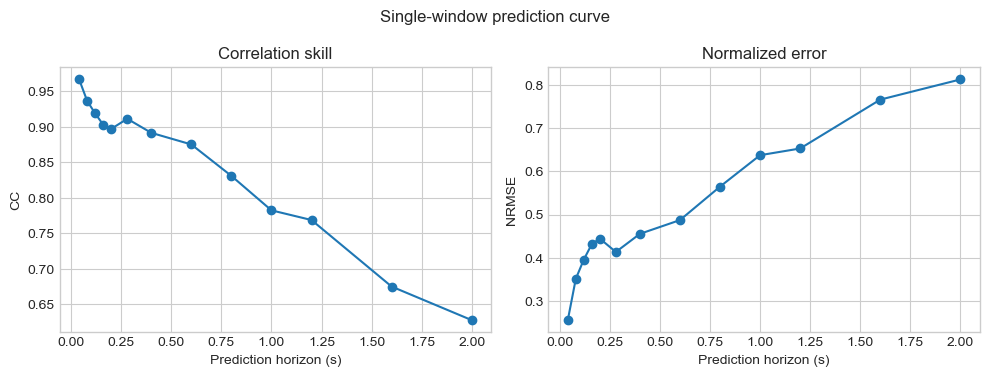

,tau_samples,theiler_samples,horizon_samples,horizon_seconds,cc,nrmse,n_valid,n_possible,valid_fraction,prediction_std,constant_prediction,status
0,10,50,2,0.04,0.9668,0.2557,2928,2928,1.0,0.9540,False,ok
1,10,50,4,0.08,0.9364,0.3513,2926,2926,1.0,0.9434,False,ok
2,10,50,6,0.12,0.9188,0.3958,2924,2924,1.0,0.9367,False,ok
3,10,50,8,0.16,0.9029,0.4317,2922,2922,1.0,0.9341,False,ok
4,10,50,10,0.20,0.8971,0.4442,2920,2920,1.0,0.9328,False,ok
5,10,50,14,0.28,0.9113,0.4134,2916,2916,1.0,0.9360,False,ok
6,10,50,20,0.40,0.8915,0.4553,2910,2910,1.0,0.9234,False,ok
7,10,50,30,0.60,0.8752,0.4871,2900,2900,1.0,0.9182,False,ok
8,10,50,40,0.80,0.8308,0.5645,2890,2890,1.0,0.9103,False,ok
9,10,50,50,1.00,0.7823,0.6372,2880,2880,1.0,0.8999,False,ok


In [5]:
RESULT_COLUMNS = [
    "session",
    "state",
    "window_id",
    "representation",
    "fs",
    "tau_samples",
    "theiler_samples",
    "horizon_samples",
    "horizon_seconds",
    "cc",
    "nrmse",
    "n_valid",
    "n_possible",
    "valid_fraction",
    "prediction_std",
    "constant_prediction",
    "status",
]


def evaluate_window(
    signal,
    fs,
    representation,
    horizons_seconds,
):
    '''Compute one window's prediction curve.'''
    normalized = standardize_window(signal)
    tau_samples = int(
        seconds_to_samples(TAU_SECONDS[representation], fs)
    )
    theiler_samples = int(
        seconds_to_samples(THEILER_SECONDS, fs)
    )
    rows = []

    for horizon_seconds in horizons_seconds:
        horizon_samples = int(
            seconds_to_samples(horizon_seconds, fs)
        )
        row = {
            "tau_samples": tau_samples,
            "theiler_samples": theiler_samples,
            "horizon_samples": horizon_samples,
            "horizon_seconds": float(horizon_seconds),
        }
        try:
            result = simplex_projection(
                signal=normalized,
                tau=tau_samples,
                m=EMBEDDING_DIMENSION,
                horizon=horizon_samples,
                theiler_window=theiler_samples,
            )
            target = result.y_true[result.valid]
            scale = float(np.std(target))
            metrics = prediction_metrics(result, scale)
            prediction_std = float(
                np.std(result.y_pred[result.valid])
            )
            row.update({
                "cc": metrics.cc,
                "nrmse": metrics.nrmse,
                "n_valid": metrics.n_valid,
                "n_possible": len(result.y_true),
                "valid_fraction": (
                    metrics.n_valid / len(result.y_true)
                ),
                "prediction_std": prediction_std,
                "constant_prediction": bool(
                    np.isclose(prediction_std, 0.0)
                ),
                "status": "ok",
            })
        except ValueError as error:
            row.update({
                "cc": np.nan,
                "nrmse": np.nan,
                "n_valid": 0,
                "n_possible": np.nan,
                "valid_fraction": 0.0,
                "prediction_std": np.nan,
                "constant_prediction": False,
                "status": str(error),
            })
        rows.append(row)

    return pd.DataFrame(rows)


def run_state_windows(batch, state):
    '''Evaluate both representations for all windows in one state.'''
    frames = []
    representation_keys = {
        "Raw": "raw",
        "Processed": "processed",
    }

    for representation, key in representation_keys.items():
        for index, window_id in enumerate(batch["window_id"]):
            curve = evaluate_window(
                signal=batch[key][index],
                fs=float(batch["fs"]),
                representation=representation,
                horizons_seconds=HORIZON_SECONDS,
            )
            curve.insert(0, "fs", float(batch["fs"]))
            curve.insert(0, "representation", representation)
            curve.insert(0, "window_id", int(window_id))
            curve.insert(0, "state", state)
            curve.insert(0, "session", SESSION)
            frames.append(curve)

    return pd.concat(frames, ignore_index=True)[RESULT_COLUMNS]


single_window_curve = evaluate_window(
    signal=smoke_batch["raw"][0],
    fs=smoke_fs,
    representation="Raw",
    horizons_seconds=HORIZON_SECONDS,
)
assert (single_window_curve["status"] == "ok").all()

figure, axes = plt.subplots(1, 2, figsize=(10, 3.8))
axes[0].plot(
    single_window_curve["horizon_seconds"],
    single_window_curve["cc"],
    marker="o",
)
axes[1].plot(
    single_window_curve["horizon_seconds"],
    single_window_curve["nrmse"],
    marker="o",
)
axes[0].set(
    xlabel="Prediction horizon (s)",
    ylabel="CC",
    title="Correlation skill",
)
axes[1].set(
    xlabel="Prediction horizon (s)",
    ylabel="NRMSE",
    title="Normalized error",
)
figure.suptitle("Single-window prediction curve")
figure.tight_layout()
plt.show()
display(single_window_curve.round(4))

## Cell 6 — Run all Awake windows

Both representations use the same horizon grid, Theiler exclusion,
metric definitions, and normalization policy.

In [6]:
awake_results = run_state_windows(
    state_batches["Awake"],
    "Awake",
)
awake_results.to_csv(
    OUTPUT_DIR / "session_1_awake_window_results.csv",
    index=False,
)
display(
    awake_results.groupby("representation")
    .agg(
        n_windows=("window_id", "nunique"),
        n_rows=("window_id", "size"),
        failed=("status", lambda values: (values != "ok").sum()),
    )
    .reset_index()
)

,representation,n_windows,n_rows,failed
0,Processed,14,182,0
1,Raw,14,182,0


## Cell 7 — Run all Drowsy windows

No parameter is tuned separately for Drowsy windows.

In [7]:
drowsy_results = run_state_windows(
    state_batches["Drowsy"],
    "Drowsy",
)
drowsy_results.to_csv(
    OUTPUT_DIR / "session_1_drowsy_window_results.csv",
    index=False,
)
display(
    drowsy_results.groupby("representation")
    .agg(
        n_windows=("window_id", "nunique"),
        n_rows=("window_id", "size"),
        failed=("status", lambda values: (values != "ok").sum()),
    )
    .reset_index()
)

,representation,n_windows,n_rows,failed
0,Processed,2,26,0
1,Raw,2,26,0


## Cell 8 — Quality control

QC is performed before interpreting prediction curves. The NRMSE
extreme threshold is a screening value, not an inferential cutoff.

,check,value
0,failed predictions,0.0
1,undefined CC,0.0
2,constant predictions,0.0
3,NRMSE > 5.0,0.0
4,minimum valid fraction,1.0


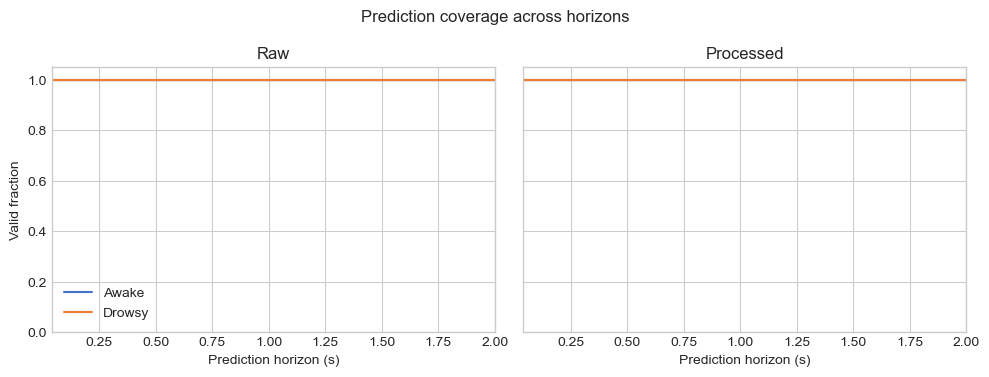

In [8]:
window_results = pd.concat(
    [awake_results, drowsy_results],
    ignore_index=True,
)
window_results.to_csv(
    OUTPUT_DIR / "session_1_window_results.csv",
    index=False,
)

qc_summary = (
    window_results
    .groupby(
        ["representation", "state", "horizon_seconds"],
        observed=True,
    )
    .agg(
        n_windows=("window_id", "nunique"),
        failed_predictions=(
            "status",
            lambda values: (values != "ok").sum(),
        ),
        undefined_cc=("cc", lambda values: values.isna().sum()),
        constant_predictions=("constant_prediction", "sum"),
        mean_valid_fraction=("valid_fraction", "mean"),
        min_valid_fraction=("valid_fraction", "min"),
        median_nrmse=("nrmse", "median"),
        max_nrmse=("nrmse", "max"),
    )
    .reset_index()
)
qc_summary["extreme_nrmse"] = (
    qc_summary["max_nrmse"] > EXTREME_NRMSE_LEVEL
)
qc_summary.to_csv(
    OUTPUT_DIR / "session_1_qc_summary.csv",
    index=False,
)

qc_totals = pd.DataFrame({
    "check": [
        "failed predictions",
        "undefined CC",
        "constant predictions",
        f"NRMSE > {EXTREME_NRMSE_LEVEL:.1f}",
        "minimum valid fraction",
    ],
    "value": [
        int((window_results["status"] != "ok").sum()),
        int(window_results["cc"].isna().sum()),
        int(window_results["constant_prediction"].sum()),
        int(
            (window_results["nrmse"] > EXTREME_NRMSE_LEVEL).sum()
        ),
        float(window_results["valid_fraction"].min()),
    ],
})
display(qc_totals)

valid_fraction_summary = (
    window_results
    .groupby(
        ["representation", "state", "horizon_seconds"],
        observed=True,
    )["valid_fraction"]
    .agg(["mean", "std"])
    .reset_index()
)

figure, axes = plt.subplots(1, 2, figsize=(10, 3.8), sharey=True)
for axis, representation in zip(axes, ("Raw", "Processed")):
    for state in ("Awake", "Drowsy"):
        subset = valid_fraction_summary[
            (valid_fraction_summary["representation"] == representation)
            & (valid_fraction_summary["state"] == state)
        ]
        x_values = subset["horizon_seconds"].to_numpy()
        mean_values = subset["mean"].to_numpy()
        sd_values = subset["std"].fillna(0.0).to_numpy()
        axis.plot(
            x_values,
            mean_values,
            color=STATE_COLORS[state],
            label=state,
        )
        axis.fill_between(
            x_values,
            np.clip(mean_values - sd_values, 0.0, 1.0),
            np.clip(mean_values + sd_values, 0.0, 1.0),
            color=STATE_COLORS[state],
            alpha=0.18,
        )
    axis.set(
        title=representation,
        xlabel="Prediction horizon (s)",
        ylabel="Valid fraction" if representation == "Raw" else "",
        xlim=(HORIZON_SECONDS.min(), HORIZON_SECONDS.max()),
        ylim=(0.0, 1.05),
    )
axes[0].legend(frameon=False)
figure.suptitle("Prediction coverage across horizons")
figure.tight_layout()
figure.savefig(
    OUTPUT_DIR / "session_1_valid_fraction.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## Cell 9 — Aggregate across windows

Mean and sample SD are descriptive summaries at window level. No
inferential test is performed in this validation notebook.

In [9]:
valid_results = window_results[
    (window_results["status"] == "ok")
    & window_results["cc"].notna()
    & window_results["nrmse"].notna()
].copy()

curve_summary = (
    valid_results
    .groupby(
        ["representation", "state", "horizon_seconds"],
        observed=True,
    )
    .agg(
        mean_cc=("cc", "mean"),
        sd_cc=("cc", "std"),
        mean_nrmse=("nrmse", "mean"),
        sd_nrmse=("nrmse", "std"),
        n_valid_windows=("window_id", "nunique"),
        mean_valid_fraction=("valid_fraction", "mean"),
    )
    .reset_index()
)
curve_summary.to_csv(
    OUTPUT_DIR / "session_1_curve_summary.csv",
    index=False,
)
display(curve_summary.round(4))

,representation,state,horizon_seconds,mean_cc,sd_cc,mean_nrmse,sd_nrmse,n_valid_windows,mean_valid_fraction
0,Processed,Awake,0.04,0.9808,0.0085,0.1919,0.0373,14,1.0
1,Processed,Awake,0.08,0.9591,0.0170,0.2785,0.0518,14,1.0
2,Processed,Awake,0.12,0.9604,0.0154,0.2744,0.0488,14,1.0
3,Processed,Awake,0.16,0.9586,0.0154,0.2809,0.0473,14,1.0
4,Processed,Awake,0.20,0.9542,0.0185,0.2945,0.0525,14,1.0
5,Processed,Awake,0.28,0.9449,0.0174,0.3237,0.0479,14,1.0
6,Processed,Awake,0.40,0.9288,0.0221,0.3666,0.0527,14,1.0
7,Processed,Awake,0.60,0.8913,0.0297,0.4496,0.0576,14,1.0
8,Processed,Awake,0.80,0.8525,0.0371,0.5194,0.0592,14,1.0
9,Processed,Awake,1.00,0.7896,0.0443,0.6121,0.0565,14,1.0


## Cell 10 — Raw PPG prediction curves

Lines show the window-level mean; shaded bands show mean ± SD.

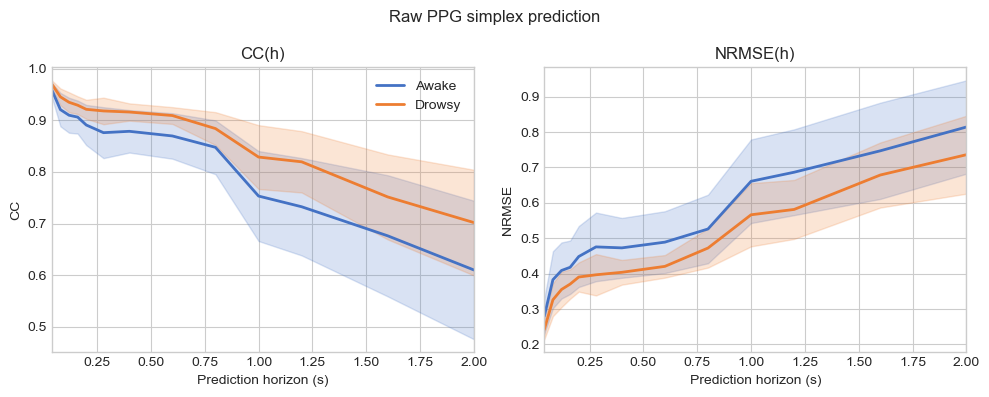

In [10]:
def plot_prediction_curves(summary, representation, output_path):
    '''Plot mean prediction curves with window-level SD bands.'''
    figure, axes = plt.subplots(1, 2, figsize=(10, 4.0))
    metric_settings = (
        ("mean_cc", "sd_cc", "CC", "CC(h)"),
        ("mean_nrmse", "sd_nrmse", "NRMSE", "NRMSE(h)"),
    )

    for axis, settings in zip(axes, metric_settings):
        mean_column, sd_column, ylabel, title = settings
        for state in ("Awake", "Drowsy"):
            subset = summary[
                (summary["representation"] == representation)
                & (summary["state"] == state)
            ].sort_values("horizon_seconds")
            x_values = subset["horizon_seconds"].to_numpy()
            mean_values = subset[mean_column].to_numpy()
            sd_values = subset[sd_column].fillna(0.0).to_numpy()
            lower = mean_values - sd_values
            if ylabel == "NRMSE":
                lower = np.clip(lower, 0.0, None)

            axis.plot(
                x_values,
                mean_values,
                color=STATE_COLORS[state],
                linewidth=2.0,
                label=state,
            )
            axis.fill_between(
                x_values,
                lower,
                mean_values + sd_values,
                color=STATE_COLORS[state],
                alpha=0.20,
            )
        axis.set(
            title=title,
            xlabel="Prediction horizon (s)",
            ylabel=ylabel,
            xlim=(HORIZON_SECONDS.min(), HORIZON_SECONDS.max()),
        )

    axes[0].legend(frameon=False)
    figure.suptitle(f"{representation} PPG simplex prediction")
    figure.tight_layout()
    figure.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()


plot_prediction_curves(
    curve_summary,
    "Raw",
    OUTPUT_DIR / "session_1_raw_prediction_curves.png",
)

## Cell 11 — Processed PPG prediction curves

The same axes, aggregation, and uncertainty display are used as for
Raw PPG.

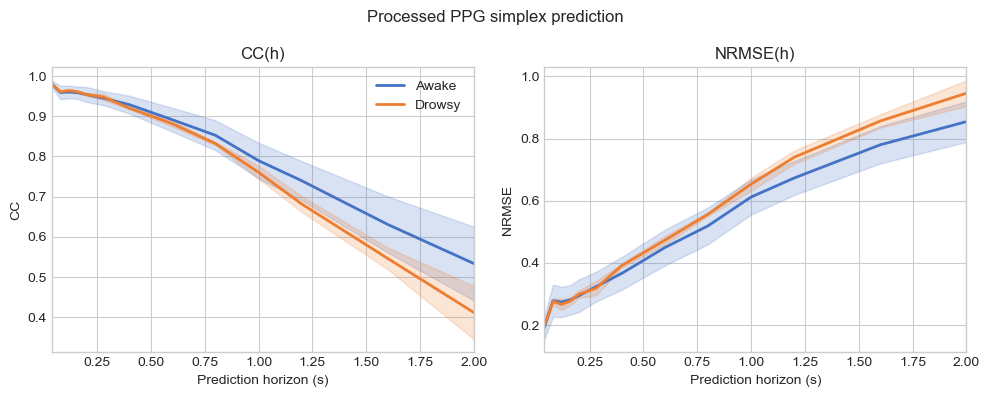

In [11]:
plot_prediction_curves(
    curve_summary,
    "Processed",
    OUTPUT_DIR / "session_1_processed_prediction_curves.png",
)

## Cell 12 — Raw versus Processed sanity comparison

These descriptors summarize curve shape and between-window variation.
Thresholds are exploratory and carry no physiological interpretation.

In [12]:
def first_horizon_below(group, column, level):
    '''Return the first horizon below a descriptive level.'''
    selected = group.loc[group[column] < level, "horizon_seconds"]
    return float(selected.iloc[0]) if len(selected) else np.nan


def plateau_horizon(group, column, tolerance, min_points):
    '''Find the first stable tail within a fixed value range.'''
    ordered = group.sort_values("horizon_seconds")
    values = ordered[column].to_numpy()
    horizons = ordered["horizon_seconds"].to_numpy()
    for index in range(len(values) - min_points + 1):
        tail = values[index:]
        if np.ptp(tail) <= tolerance:
            return float(horizons[index])
    return np.nan


comparison_rows = []
for (representation, state), group in curve_summary.groupby(
    ["representation", "state"],
    observed=True,
):
    ordered = group.sort_values("horizon_seconds")
    first = ordered.iloc[0]
    last = ordered.iloc[-1]
    comparison_rows.append({
        "representation": representation,
        "state": state,
        "mean_cc_across_horizons": ordered["mean_cc"].mean(),
        "cc_short": first["mean_cc"],
        "cc_long": last["mean_cc"],
        "cc_drop": first["mean_cc"] - last["mean_cc"],
        "mean_nrmse_across_horizons": ordered["mean_nrmse"].mean(),
        "nrmse_short": first["mean_nrmse"],
        "nrmse_long": last["mean_nrmse"],
        "nrmse_rise": last["mean_nrmse"] - first["mean_nrmse"],
        "median_sd_cc": ordered["sd_cc"].median(),
        "median_sd_nrmse": ordered["sd_nrmse"].median(),
        "first_cc_below_0_5_seconds": first_horizon_below(
            ordered,
            "mean_cc",
            CC_COLLAPSE_LEVEL,
        ),
        "nrmse_plateau_seconds": plateau_horizon(
            ordered,
            "mean_nrmse",
            NRMSE_PLATEAU_TOLERANCE,
            NRMSE_PLATEAU_MIN_POINTS,
        ),
    })

comparison_summary = pd.DataFrame(comparison_rows)
comparison_summary.to_csv(
    OUTPUT_DIR / "session_1_raw_processed_comparison.csv",
    index=False,
)
display(comparison_summary.round(4))

,representation,state,mean_cc_across_horizons,cc_short,cc_long,cc_drop,mean_nrmse_across_horizons,nrmse_short,nrmse_long,nrmse_rise,median_sd_cc,median_sd_nrmse,first_cc_below_0_5_seconds,nrmse_plateau_seconds
0,Processed,Awake,0.8557,0.9808,0.5336,0.4472,0.4538,0.1919,0.8547,0.6628,0.0221,0.0527,NaN,NaN
1,Processed,Drowsy,0.8309,0.9804,0.4117,0.5687,0.4811,0.1970,0.9462,0.7492,0.0049,0.0138,2.0,NaN
2,Raw,Awake,0.8331,0.9589,0.6100,0.3489,0.5239,0.2799,0.8143,0.5343,0.0441,0.0873,NaN,NaN
3,Raw,Drowsy,0.8792,0.9702,0.7018,0.2684,0.4570,0.2421,0.7360,0.4939,0.0193,0.0500,NaN,NaN


## Cell 13 — Baseline parameter summary

The simplex algorithm, embedding parameters, leave-one-out prediction,
and metrics are fixed for this validation. Remaining choices require
dedicated sensitivity analyses before full-dataset inference.

In [13]:
baseline_summary = pd.DataFrame([
    {
        "parameter": "Session",
        "value": SESSION,
        "status": "selected for validation",
    },
    {
        "parameter": "Window size",
        "value": f"{WINDOW_SIZE_SECONDS} s",
        "status": "selected for validation",
    },
    {
        "parameter": "Embedding dimension m",
        "value": EMBEDDING_DIMENSION,
        "status": "frozen",
    },
    {
        "parameter": "Raw tau",
        "value": f"{TAU_SECONDS['Raw']:.2f} s",
        "status": "frozen",
    },
    {
        "parameter": "Processed tau",
        "value": f"{TAU_SECONDS['Processed']:.2f} s",
        "status": "frozen",
    },
    {
        "parameter": "Predictor",
        "value": "Simplex projection",
        "status": "frozen",
    },
    {
        "parameter": "Neighbors",
        "value": "k = m + 1 = 9",
        "status": "frozen",
    },
    {
        "parameter": "Distance",
        "value": "Euclidean",
        "status": "frozen",
    },
    {
        "parameter": "Weighting",
        "value": "exponential simplex weighting",
        "status": "frozen",
    },
    {
        "parameter": "Validation",
        "value": "leave-one-out with temporal exclusion",
        "status": "frozen",
    },
    {
        "parameter": "Metrics",
        "value": "CC and NRMSE",
        "status": "frozen",
    },
    {
        "parameter": "Theiler window",
        "value": f"{THEILER_SECONDS:.2f} s",
        "status": "baseline, not frozen",
    },
    {
        "parameter": "Horizon grid",
        "value": ", ".join(
            f"{value:.2f}" for value in HORIZON_SECONDS
        ) + " s",
        "status": "baseline, not frozen",
    },
    {
        "parameter": "Hmax",
        "value": f"{HORIZON_SECONDS.max():.2f} s",
        "status": "baseline, not frozen",
    },
    {
        "parameter": "Signal normalization",
        "value": SIGNAL_NORMALIZATION,
        "status": "baseline, not frozen",
    },
    {
        "parameter": "NRMSE denominator",
        "value": NRMSE_NORMALIZATION,
        "status": "baseline, not frozen",
    },
])
baseline_summary.to_csv(
    OUTPUT_DIR / "session_1_baseline_parameters.csv",
    index=False,
)
display(baseline_summary)

validation_record = pd.DataFrame([{
    "session": SESSION,
    "awake_windows": int(
        availability.loc[
            availability["state"] == "Awake",
            "n_windows",
        ].iloc[0]
    ),
    "drowsy_windows": int(
        availability.loc[
            availability["state"] == "Drowsy",
            "n_windows",
        ].iloc[0]
    ),
    "failed_predictions": int(
        (window_results["status"] != "ok").sum()
    ),
    "undefined_cc": int(window_results["cc"].isna().sum()),
    "minimum_valid_fraction": float(
        window_results["valid_fraction"].min()
    ),
    "scope": "exploratory core validation only",
}])
display(validation_record)

print(
    "Do not use this notebook for determinism, chaos, surrogate "
    "significance, or population-level state inference."
)

,parameter,value,status
0,Session,sample_1.csv,selected for validation
1,Window size,60 s,selected for validation
2,Embedding dimension m,8,frozen
3,Raw tau,0.20 s,frozen
4,Processed tau,0.16 s,frozen
5,Predictor,Simplex projection,frozen
6,Neighbors,k = m + 1 = 9,frozen
7,Distance,Euclidean,frozen
8,Weighting,exponential simplex weighting,frozen
9,Validation,leave-one-out with temporal exclusion,frozen


,session,awake_windows,drowsy_windows,failed_predictions,undefined_cc,minimum_valid_fraction,scope
0,sample_1.csv,14,2,0,0,1.0,exploratory core validation only


Do not use this notebook for determinism, chaos, surrogate significance, or population-level state inference.


## Cell 14 — Load 120 s and 180 s windows

The same session, SQI/stationarity policy, representations, and model
parameters are retained. Coverage is checked before any comparison.

In [14]:
WINDOW_SIZES_SECONDS = (60, 120, 180)

extended_awake, extended_drowsy = get_data(
    SESSION,
    window_sizes=(120, 180),
    stationarity=STATIONARITY_POLICY,
)

window_size_batches = {
    60: state_batches,
    120: {
        "Awake": extended_awake[120],
        "Drowsy": extended_drowsy[120],
    },
    180: {
        "Awake": extended_awake[180],
        "Drowsy": extended_drowsy[180],
    },
}

coverage_rows = []
for window_size, batches in window_size_batches.items():
    for state, batch in batches.items():
        coverage_rows.append({
            "session": SESSION,
            "window_size_seconds": window_size,
            "state": state,
            "n_windows": len(batch["window_id"]),
            "n_samples": batch["n_samples"],
            "fs": batch["fs"],
        })

window_size_coverage = pd.DataFrame(coverage_rows)
display(window_size_coverage)

if (
    window_size_coverage.query(
        "window_size_seconds in [120, 180] and state == 'Drowsy'"
    )["n_windows"].sum()
    == 0
):
    print(
        "No Drowsy windows at 120/180 s pass the matched "
        "stationarity policy; the three-size comparison uses Awake."
    )

,session,window_size_seconds,state,n_windows,n_samples,fs
0,sample_1.csv,60,Awake,14,3000,50.0
1,sample_1.csv,60,Drowsy,2,3000,50.0
2,sample_1.csv,120,Awake,8,6000,50.0
3,sample_1.csv,120,Drowsy,0,6000,50.0
4,sample_1.csv,180,Awake,5,9000,50.0
5,sample_1.csv,180,Drowsy,0,9000,50.0


No Drowsy windows at 120/180 s pass the matched stationarity policy; the three-size comparison uses Awake.


## Cell 15 — Run 120 s and 180 s windows

Every available window is evaluated with the same horizon grid and
prediction protocol used for 60 s. Empty state groups are skipped.

In [15]:
window_size_frames = [
    window_results.assign(
        window_size_seconds=WINDOW_SIZE_SECONDS
    )
]

for window_size in (120, 180):
    for state, batch in window_size_batches[window_size].items():
        if len(batch["window_id"]) == 0:
            continue
        size_results = run_state_windows(batch, state)
        size_results["window_size_seconds"] = window_size
        window_size_frames.append(size_results)

window_size_results = pd.concat(
    window_size_frames,
    ignore_index=True,
)
window_size_results.to_csv(
    OUTPUT_DIR / "session_1_window_size_results.csv",
    index=False,
)

run_counts = (
    window_size_results
    .groupby(
        ["window_size_seconds", "state", "representation"],
        observed=True,
    )
    .agg(
        n_windows=("window_id", "nunique"),
        n_horizon_rows=("horizon_seconds", "size"),
        failed=("status", lambda values: (values != "ok").sum()),
    )
    .reset_index()
)
display(run_counts)

,window_size_seconds,state,representation,n_windows,n_horizon_rows,failed
0,60,Awake,Processed,14,182,0
1,60,Awake,Raw,14,182,0
2,60,Drowsy,Processed,2,26,0
3,60,Drowsy,Raw,2,26,0
4,120,Awake,Processed,8,104,0
5,120,Awake,Raw,8,104,0
6,180,Awake,Processed,5,65,0
7,180,Awake,Raw,5,65,0


## Cell 16 — Window-size QC and mean aggregation

Only arithmetic means are calculated. No SD band or inferential test
is used in this window-size comparison.

In [16]:
window_size_qc = (
    window_size_results
    .groupby(
        ["window_size_seconds", "state", "representation"],
        observed=True,
    )
    .agg(
        n_windows=("window_id", "nunique"),
        failed_predictions=(
            "status",
            lambda values: (values != "ok").sum(),
        ),
        undefined_cc=("cc", lambda values: values.isna().sum()),
        constant_predictions=("constant_prediction", "sum"),
        mean_valid_fraction=("valid_fraction", "mean"),
        minimum_valid_fraction=("valid_fraction", "min"),
    )
    .reset_index()
)

valid_window_size_results = window_size_results[
    (window_size_results["status"] == "ok")
    & window_size_results["cc"].notna()
    & window_size_results["nrmse"].notna()
].copy()

window_size_mean = (
    valid_window_size_results
    .groupby(
        [
            "window_size_seconds",
            "representation",
            "state",
            "horizon_seconds",
        ],
        observed=True,
    )
    .agg(
        mean_cc=("cc", "mean"),
        mean_nrmse=("nrmse", "mean"),
        n_windows=("window_id", "nunique"),
        mean_valid_fraction=("valid_fraction", "mean"),
    )
    .reset_index()
)
window_size_mean.to_csv(
    OUTPUT_DIR / "session_1_window_size_mean_curves.csv",
    index=False,
)
window_size_qc.to_csv(
    OUTPUT_DIR / "session_1_window_size_qc.csv",
    index=False,
)

coverage_wide = window_size_coverage.pivot(
    index="state",
    columns="window_size_seconds",
    values="n_windows",
)
common_states = coverage_wide.index[
    (coverage_wide[list(WINDOW_SIZES_SECONDS)] > 0).all(axis=1)
].tolist()
assert common_states, "No state is available at all window sizes."

display(window_size_qc)
print("States comparable across 60/120/180 s:", common_states)

,window_size_seconds,state,representation,n_windows,failed_predictions,undefined_cc,constant_predictions,mean_valid_fraction,minimum_valid_fraction
0,60,Awake,Processed,14,0,0,0,1.0,1.0
1,60,Awake,Raw,14,0,0,0,1.0,1.0
2,60,Drowsy,Processed,2,0,0,0,1.0,1.0
3,60,Drowsy,Raw,2,0,0,0,1.0,1.0
4,120,Awake,Processed,8,0,0,0,1.0,1.0
5,120,Awake,Raw,8,0,0,0,1.0,1.0
6,180,Awake,Processed,5,0,0,0,1.0,1.0
7,180,Awake,Raw,5,0,0,0,1.0,1.0


States comparable across 60/120/180 s: ['Awake']


## Cell 17 — Mean curves across window sizes

The figures contain no SD bands. Only states available at all three
sizes are plotted, which is Awake for this selected session.

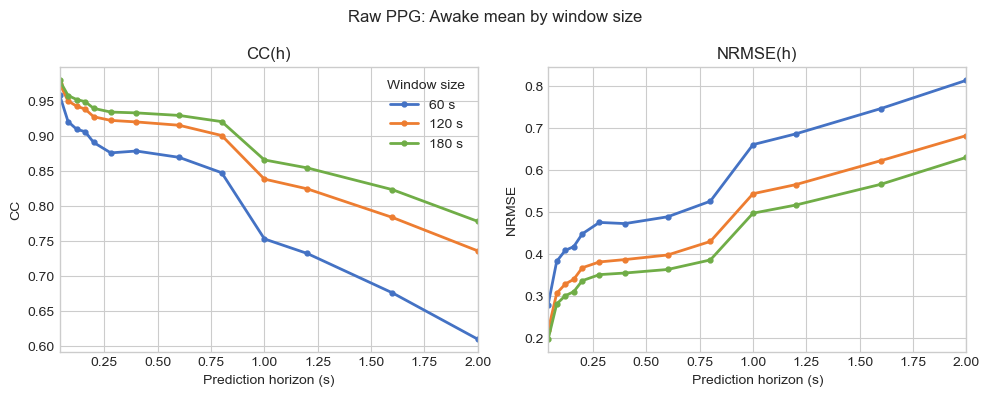

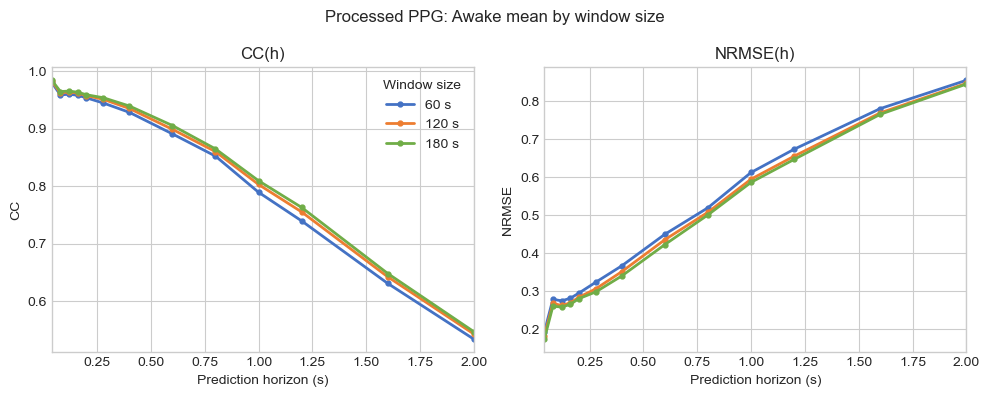

In [17]:
WINDOW_SIZE_COLORS = {
    60: "#4472C4",
    120: "#ED7D31",
    180: "#70AD47",
}


def plot_window_size_means(summary, representation, state):
    '''Plot mean CC and NRMSE curves for all window sizes.'''
    figure, axes = plt.subplots(1, 2, figsize=(10, 4.0))
    metric_settings = (
        ("mean_cc", "CC", "CC(h)"),
        ("mean_nrmse", "NRMSE", "NRMSE(h)"),
    )

    for axis, settings in zip(axes, metric_settings):
        column, ylabel, title = settings
        for window_size in WINDOW_SIZES_SECONDS:
            subset = summary[
                (summary["representation"] == representation)
                & (summary["state"] == state)
                & (
                    summary["window_size_seconds"]
                    == window_size
                )
            ].sort_values("horizon_seconds")
            axis.plot(
                subset["horizon_seconds"],
                subset[column],
                color=WINDOW_SIZE_COLORS[window_size],
                linewidth=2.0,
                marker="o",
                markersize=3.5,
                label=f"{window_size} s",
            )
        axis.set(
            title=title,
            xlabel="Prediction horizon (s)",
            ylabel=ylabel,
            xlim=(HORIZON_SECONDS.min(), HORIZON_SECONDS.max()),
        )

    axes[0].legend(title="Window size", frameon=False)
    figure.suptitle(
        f"{representation} PPG: {state} mean by window size"
    )
    figure.tight_layout()
    output_name = (
        f"session_1_{representation.lower()}_"
        f"{state.lower()}_window_size_means.png"
    )
    figure.savefig(
        OUTPUT_DIR / output_name,
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()


for representation in ("Raw", "Processed"):
    for state in common_states:
        plot_window_size_means(
            window_size_mean,
            representation,
            state,
        )

## Cell 18 — Descriptive comparison against 60 s

Differences are calculated between mean curves on the common physical
horizon grid. They describe window-size sensitivity only.

In [18]:
comparison_rows = []
for representation in ("Raw", "Processed"):
    for state in common_states:
        group = window_size_mean[
            (window_size_mean["representation"] == representation)
            & (window_size_mean["state"] == state)
        ]
        reference = group[
            group["window_size_seconds"] == 60
        ][
            ["horizon_seconds", "mean_cc", "mean_nrmse"]
        ].rename(columns={
            "mean_cc": "mean_cc_60",
            "mean_nrmse": "mean_nrmse_60",
        })

        for window_size in WINDOW_SIZES_SECONDS:
            current = group[
                group["window_size_seconds"] == window_size
            ].sort_values("horizon_seconds")
            paired = current.merge(
                reference,
                on="horizon_seconds",
                validate="one_to_one",
            )
            comparison_rows.append({
                "representation": representation,
                "state": state,
                "window_size_seconds": window_size,
                "n_windows": int(current["n_windows"].min()),
                "mean_cc_across_horizons": current[
                    "mean_cc"
                ].mean(),
                "mean_nrmse_across_horizons": current[
                    "mean_nrmse"
                ].mean(),
                "mean_abs_cc_difference_vs_60": (
                    paired["mean_cc"] - paired["mean_cc_60"]
                ).abs().mean(),
                "mean_abs_nrmse_difference_vs_60": (
                    paired["mean_nrmse"]
                    - paired["mean_nrmse_60"]
                ).abs().mean(),
                "cc_at_shortest_horizon": current.iloc[0][
                    "mean_cc"
                ],
                "cc_at_longest_horizon": current.iloc[-1][
                    "mean_cc"
                ],
                "nrmse_at_shortest_horizon": current.iloc[0][
                    "mean_nrmse"
                ],
                "nrmse_at_longest_horizon": current.iloc[-1][
                    "mean_nrmse"
                ],
            })

window_size_comparison = pd.DataFrame(comparison_rows)
window_size_comparison.to_csv(
    OUTPUT_DIR / "session_1_window_size_comparison.csv",
    index=False,
)
display(window_size_comparison.round(4))

print(
    "The comparison is descriptive. Window counts differ by size, "
    "and Drowsy has no matched 120/180 s windows in session 1."
)

,representation,state,window_size_seconds,n_windows,mean_cc_across_horizons,mean_nrmse_across_horizons,mean_abs_cc_difference_vs_60,mean_abs_nrmse_difference_vs_60,cc_at_shortest_horizon,cc_at_longest_horizon,nrmse_at_shortest_horizon,nrmse_at_longest_horizon
0,Raw,Awake,60,14,0.8331,0.5239,0.0000,0.0000,0.9589,0.6100,0.2799,0.8143
1,Raw,Awake,120,8,0.8904,0.4288,0.0573,0.0951,0.9749,0.7361,0.2190,0.6826
2,Raw,Awake,180,5,0.9090,0.3919,0.0760,0.1320,0.9796,0.7782,0.1973,0.6307
3,Processed,Awake,60,14,0.8557,0.4538,0.0000,0.0000,0.9808,0.5336,0.1919,0.8547
4,Processed,Awake,120,8,0.8631,0.4407,0.0074,0.0131,0.9831,0.5426,0.1815,0.8466
5,Processed,Awake,180,5,0.8670,0.4339,0.0113,0.0199,0.9846,0.5466,0.1734,0.8448


The comparison is descriptive. Window counts differ by size, and Drowsy has no matched 120/180 s windows in session 1.


## Tổng hợp kết quả theo kích thước cửa sổ

Cell 17 trình bày đường trung bình `CC(h)` và `NRMSE(h)` của Awake tại các
cửa sổ 60, 120 và 180 s. Session 1 có lần lượt 14, 8 và 5 Awake windows vượt
qua cùng chính sách SQI/stationarity. Không có Drowsy window 120 hoặc 180 s
thỏa điều kiện, nên hình không trình bày so sánh window size cho Drowsy.

### Raw PPG

- `CC(h)` giảm theo prediction horizon ở cả ba kích thước cửa sổ. Từ horizon
  0,04 đến 2,00 s, mean CC thay đổi từ 0,959 xuống 0,610 với cửa sổ 60 s;
  từ 0,975 xuống 0,736 với 120 s; và từ 0,980 xuống 0,778 với 180 s.
- `NRMSE(h)` tăng theo prediction horizon. Mean NRMSE thay đổi từ 0,280 lên
  0,814 với 60 s; từ 0,219 lên 0,683 với 120 s; và từ 0,197 lên 0,631 với
  180 s.
- Mean CC trên toàn bộ horizon lần lượt là 0,833, 0,890 và 0,909 cho cửa sổ
  60, 120 và 180 s. Mean NRMSE tương ứng là 0,524, 0,429 và 0,392.

### Processed PPG

- `CC(h)` giảm theo prediction horizon và ba đường mean nằm gần nhau. Từ
  horizon 0,04 đến 2,00 s, mean CC thay đổi từ 0,981 xuống 0,534 với 60 s;
  từ 0,983 xuống 0,543 với 120 s; và từ 0,985 xuống 0,547 với 180 s.
- `NRMSE(h)` tăng theo prediction horizon. Mean NRMSE thay đổi từ 0,192 lên
  0,855 với 60 s; từ 0,182 lên 0,847 với 120 s; và từ 0,173 lên 0,845 với
  180 s.
- Mean CC trên toàn bộ horizon lần lượt là 0,856, 0,863 và 0,867 cho cửa sổ
  60, 120 và 180 s. Mean NRMSE tương ứng là 0,454, 0,441 và 0,434.

Các số liệu trên là thống kê mô tả bằng mean, không kèm SD và không bao gồm
kiểm định thống kê hoặc diễn giải sinh lý.

,window_size_seconds,state,n_windows
0,60,Awake,24
1,60,Drowsy,7
2,120,Awake,11
3,120,Drowsy,1
4,180,Awake,6
5,180,Drowsy,1


,n_predictions,failed_predictions,undefined_cc,constant_predictions,minimum_valid_fraction
0,650,0,0,0,1.0


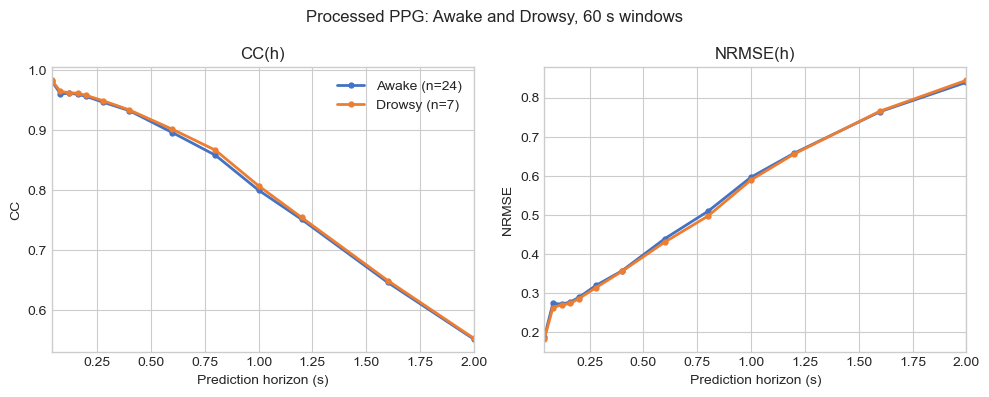

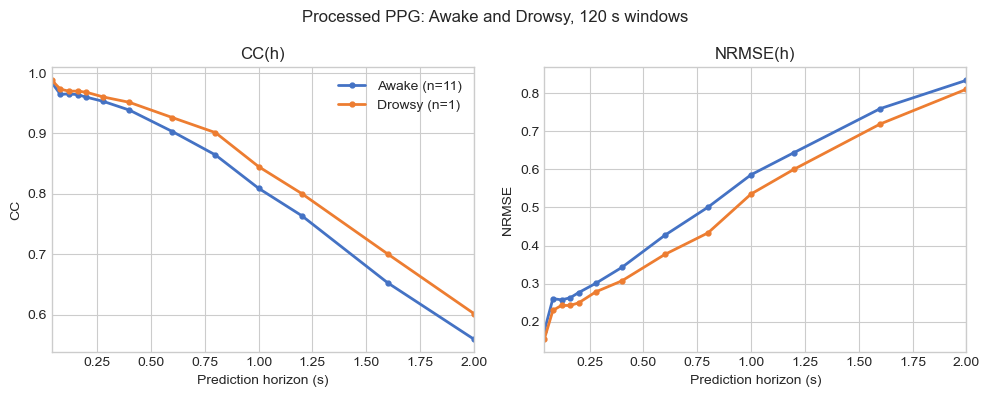

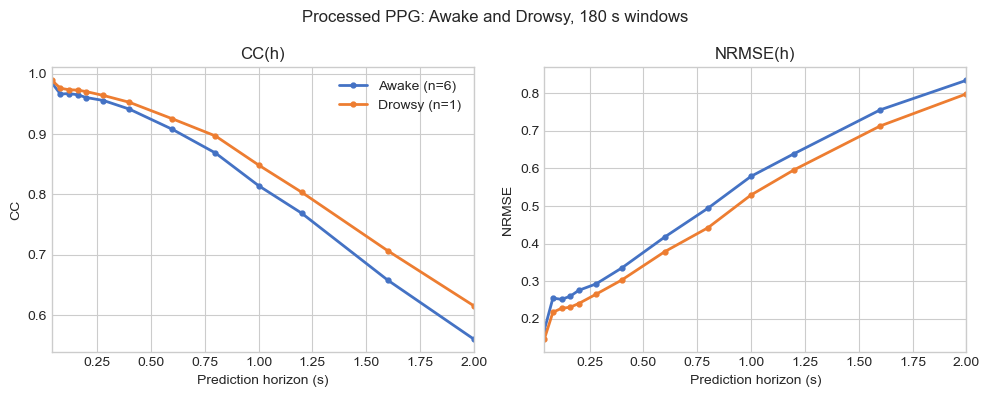

The 120 s and 180 s Drowsy means each contain one window; all curves are descriptive means without SD.


In [19]:
PROCESSED_STATE_WINDOW_SIZES = (60, 120, 180)

processed_awake, processed_drowsy = get_data(
    SESSION,
    window_sizes=PROCESSED_STATE_WINDOW_SIZES,
    stationarity="processed",
)
processed_state_batches = {
    window_size: {
        "Awake": processed_awake[window_size],
        "Drowsy": processed_drowsy[window_size],
    }
    for window_size in PROCESSED_STATE_WINDOW_SIZES
}

processed_state_frames = []
processed_coverage_rows = []

for window_size, batches in processed_state_batches.items():
    for state, batch in batches.items():
        n_windows = len(batch["window_id"])
        processed_coverage_rows.append({
            "window_size_seconds": window_size,
            "state": state,
            "n_windows": n_windows,
        })

        for index, window_id in enumerate(batch["window_id"]):
            curve = evaluate_window(
                signal=batch["processed"][index],
                fs=float(batch["fs"]),
                representation="Processed",
                horizons_seconds=HORIZON_SECONDS,
            )
            curve.insert(0, "fs", float(batch["fs"]))
            curve.insert(0, "representation", "Processed")
            curve.insert(0, "window_id", int(window_id))
            curve.insert(0, "state", state)
            curve.insert(0, "session", SESSION)
            curve["window_size_seconds"] = window_size
            processed_state_frames.append(curve)

processed_state_results = pd.concat(
    processed_state_frames,
    ignore_index=True,
)
processed_state_coverage = pd.DataFrame(processed_coverage_rows)

processed_state_mean = (
    processed_state_results[
        (processed_state_results["status"] == "ok")
        & processed_state_results["cc"].notna()
        & processed_state_results["nrmse"].notna()
    ]
    .groupby(
        ["window_size_seconds", "state", "horizon_seconds"],
        observed=True,
    )
    .agg(
        mean_cc=("cc", "mean"),
        mean_nrmse=("nrmse", "mean"),
        n_windows=("window_id", "nunique"),
        mean_valid_fraction=("valid_fraction", "mean"),
    )
    .reset_index()
)

processed_state_results.to_csv(
    OUTPUT_DIR / "session_1_processed_state_window_size_results.csv",
    index=False,
)
processed_state_mean.to_csv(
    OUTPUT_DIR / "session_1_processed_state_window_size_means.csv",
    index=False,
)
processed_state_coverage.to_csv(
    OUTPUT_DIR / "session_1_processed_state_window_size_coverage.csv",
    index=False,
)

processed_state_qc = pd.DataFrame([{
    "n_predictions": len(processed_state_results),
    "failed_predictions": int(
        (processed_state_results["status"] != "ok").sum()
    ),
    "undefined_cc": int(processed_state_results["cc"].isna().sum()),
    "constant_predictions": int(
        processed_state_results["constant_prediction"].sum()
    ),
    "minimum_valid_fraction": float(
        processed_state_results["valid_fraction"].min()
    ),
}])
display(processed_state_coverage)
display(processed_state_qc)

for window_size in PROCESSED_STATE_WINDOW_SIZES:
    figure, axes = plt.subplots(1, 2, figsize=(10, 4.0))
    metric_settings = (
        ("mean_cc", "CC", "CC(h)"),
        ("mean_nrmse", "NRMSE", "NRMSE(h)"),
    )

    for axis, settings in zip(axes, metric_settings):
        column, ylabel, title = settings
        for state in ("Awake", "Drowsy"):
            subset = processed_state_mean[
                (
                    processed_state_mean["window_size_seconds"]
                    == window_size
                )
                & (processed_state_mean["state"] == state)
            ].sort_values("horizon_seconds")
            n_windows = int(subset["n_windows"].min())
            axis.plot(
                subset["horizon_seconds"],
                subset[column],
                color=STATE_COLORS[state],
                linewidth=2.0,
                marker="o",
                markersize=3.5,
                label=f"{state} (n={n_windows})",
            )
        axis.set(
            title=title,
            xlabel="Prediction horizon (s)",
            ylabel=ylabel,
            xlim=(HORIZON_SECONDS.min(), HORIZON_SECONDS.max()),
        )

    axes[0].legend(frameon=False)
    figure.suptitle(
        f"Processed PPG: Awake and Drowsy, {window_size} s windows"
    )
    figure.tight_layout()
    figure.savefig(
        OUTPUT_DIR
        / (
            "session_1_processed_awake_drowsy_"
            f"{window_size}s_mean_curves.png"
        ),
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

print(
    "The 120 s and 180 s Drowsy means each contain one window; "
    "all curves are descriptive means without SD."
)